# Analysis of model results

## Imports

In [1]:
import arviz as az
import bambi as bmb
import polars as  pl
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from kidney.paths import RESULTS_DIR, PREPARED_FILES, PLOT_DIR
from kidney.plotting import forestplot_oz, plot_ppc
from kidney.sign_probs import get_sign_probs, get_signif

In [2]:
## Makes Illustrator recognize text in saved PDF figures:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

## Configuration

In [3]:
az.rcParams["data.load"] = "eager"

# Analysis

In [5]:
idata_change = az.from_netcdf(RESULTS_DIR / "idata_excretion_na_empa_minus_vehicle.nc")
idata_bsl = az.from_netcdf(RESULTS_DIR / "idata_excretion_na_vehicle.nc")
idata_change

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [6]:
print("Change in glucose excretion between empa and vehicle:")
display(az.summary(idata_change, var_names=["~mu", "~1|rat"]))
print("Glucose excretion at baseline (vehicle):")
display(az.summary(idata_bsl, var_names=["~mu", "~1|rat"]))

Change in glucose excretion between empa and vehicle:


/Users/lampochka/Desktop/kidney_test/kidney/.venv/lib/python3.14/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['1|rat'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.045,0.115,-0.175,0.259,0.002,0.002,3461.0,2713.0,1.0
gtyp[fa/fa],0.344,0.389,-0.411,1.064,0.008,0.008,2505.0,2117.0,1.0
age[Young],0.071,0.177,-0.278,0.394,0.004,0.004,2125.0,1706.0,1.0
sex[M],-0.176,0.169,-0.501,0.134,0.003,0.004,2418.0,2073.0,1.0
"gtyp:age[fa/fa, Young]",-0.298,0.484,-1.296,0.560,0.010,0.008,2479.0,2311.0,1.0
"gtyp:sex[fa/fa, M]",0.835,0.497,-0.056,1.807,0.009,0.009,2757.0,2688.0,1.0
sigma_Intercept,-1.497,0.298,-2.024,-0.935,0.007,0.005,1734.0,2000.0,1.0
sigma_gtyp[fa/fa],1.422,0.345,0.743,2.024,0.008,0.006,2011.0,2166.0,1.0
sigma[0],0.235,0.077,0.120,0.375,0.002,0.003,1734.0,2000.0,1.0
sigma[1],0.235,0.077,0.120,0.375,0.002,0.003,1734.0,2000.0,1.0


Glucose excretion at baseline (vehicle):


/Users/lampochka/Desktop/kidney_test/kidney/.venv/lib/python3.14/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['1|rat'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-0.297,0.480,-1.186,0.623,0.009,0.008,2839.0,2615.0,1.0
gtyp[fa/fa],0.550,0.687,-0.749,1.810,0.014,0.014,2436.0,2184.0,1.0
age[Young],0.251,0.713,-1.038,1.624,0.015,0.015,2304.0,2103.0,1.0
sex[M],-1.055,0.685,-2.243,0.341,0.015,0.014,2055.0,2065.0,1.0
"gtyp:age[fa/fa, Young]",-0.221,0.922,-2.048,1.439,0.019,0.018,2322.0,2139.0,1.0
"gtyp:sex[fa/fa, M]",0.476,0.893,-1.264,2.075,0.019,0.017,2109.0,2281.0,1.0
sigma_Intercept,-0.032,0.268,-0.496,0.481,0.006,0.005,2478.0,2288.0,1.0
sigma_gtyp[fa/fa],0.201,0.325,-0.420,0.796,0.006,0.006,2964.0,2525.0,1.0
sigma[0],1.005,0.294,0.568,1.546,0.007,0.010,2478.0,2288.0,1.0
sigma[1],1.005,0.294,0.568,1.546,0.007,0.010,2478.0,2288.0,1.0


## Compute and plot TS for all groups

In [7]:
t_groups_change, t_groups_bsl = (
    {
        "fa/+:female:adult":   idata.posterior["Intercept"],
        "fa/+:female:young":   idata.posterior["Intercept"] + idata.posterior["age"],
        "fa/+:male:adult":     idata.posterior["Intercept"] + idata.posterior["sex"],
        "fa/+:male:young":     idata.posterior["Intercept"] + idata.posterior["sex"] + idata.posterior["age"],
        "fa/fa:female:adult":  idata.posterior["Intercept"] + idata.posterior["gtyp"],
        "fa/fa:female:young":  idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["age"] + idata.posterior["gtyp:age"],
        "fa/fa:male:adult":    idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["sex"] + idata.posterior["gtyp:sex"],
        "fa/fa:male:young":    idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["sex"] + idata.posterior["gtyp:sex"] + idata.posterior["age"] + idata.posterior["gtyp:age"],
    }
    for idata in (idata_change, idata_bsl)
)

In [8]:
ts_change, ts_vehicle = (
    {
    "fa/fa adult M":   t_groups["fa/fa:male:adult"],
    "fa/fa young M":   t_groups["fa/fa:male:young"],
    "fa/+ adult M":    t_groups["fa/+:male:adult"],
    "fa/+ young M":    t_groups["fa/+:male:young"],
    "fa/fa adult F":   t_groups["fa/fa:female:adult"],
    "fa/fa young F":   t_groups["fa/fa:female:young"],
    "fa/+ adult F":    t_groups["fa/+:female:adult"],
    "fa/+ young F":    t_groups["fa/+:female:young"],
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_change = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
})

print("Change sign probabilities:")
display(get_sign_probs(ts_change))

print("Vehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Change sign probabilities:


{'fa/fa adult M': 0.993,
 'fa/fa young M': 0.97275,
 'fa/+ adult M': 0.1645,
 'fa/+ young M': 0.3055,
 'fa/fa adult F': 0.86575,
 'fa/fa young F': 0.65725,
 'fa/+ adult F': 0.671,
 'fa/+ young F': 0.78075}

Vehicle sign probabilities:


{'fa/fa adult M': 0.2425,
 'fa/fa young M': 0.28175,
 'fa/+ adult M': 0.017,
 'fa/+ young M': 0.02275,
 'fa/fa adult F': 0.713,
 'fa/fa young F': 0.717,
 'fa/+ adult F': 0.25675,
 'fa/+ young F': 0.4715}

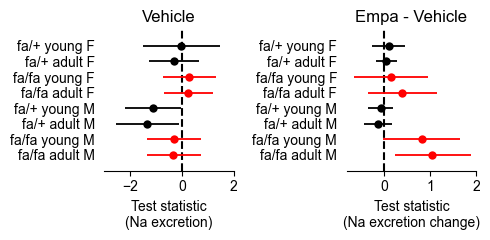

In [11]:
f, axes = plt.subplots(1, 2, figsize=(5, 2.5))
axes[1] = forestplot_oz(axes[1], ts_change);
axes[1].set_title("Empa - Vehicle");

axes[0] = forestplot_oz(axes[0], ts_vehicle);
axes[0].set_title("Vehicle");

for ax in axes:
    ax.spines[['top', 'right', 'left']].set_visible(False)
axes[1].set_xlabel('Test statistic\n(Na excretion change)')
axes[0].set_xlabel('Test statistic\n(Na excretion)')

axes[0].set_xlim(-3, 2)
axes[1].set_xlim(-0.8, 2)

f.tight_layout()
# f.savefig(PLOT_DIR / "ts_ExcretionNa_groups.pdf", bbox_inches="tight")

## Compute and plot TS representing the difference between fa/fa and fa/+ genotypes

In [12]:
ts_change, ts_vehicle = (
    {
        "M adult":   t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"],
        "M young":   t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"],
        "M": (t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"] + t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"])/2,
        "F adult": t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"],
        "F young": t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"],    
        "F": (t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"] + t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"])/2
        # "adult": (t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"] + t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"])/2,
        # "young": (t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"] + t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"])/2
       
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_gtyp = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
})

print("Change sign probabilities:")
display(get_sign_probs(ts_change))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Change sign probabilities:


{'M adult': 0.993,
 'M young': 0.97575,
 'M': 0.9945,
 'F adult': 0.82525,
 'F young': 0.5475,
 'F': 0.72475}


Vehicle sign probabilities:


{'M adult': 0.90275,
 'M young': 0.8665,
 'M': 0.93075,
 'F adult': 0.79425,
 'F young': 0.64925,
 'F': 0.761}

[]

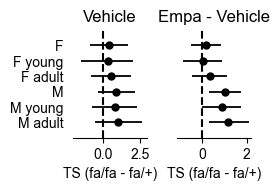

In [13]:
f, axes = plt.subplots(1, 2, figsize=(2.3, 1.4))
plt.subplots_adjust(wspace=0.4)

for ax, ts_, tle in zip(axes, (ts_vehicle, ts_change), ('Vehicle', 'Empa - Vehicle')):
    ax = forestplot_oz(ax, ts_);
    ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('TS (fa/fa - fa/+)')


axes[0].set_xlim(-2,3)
axes[1].set_xlim(-1.1,2.2)
# axes[1].set_xticks([-0.01, 0], [-0.01, 0])
# axes[0].set_xticks([-0.01, 0, 0.01], [-0.01, 0, 0.01])


axes[1].set_yticks([],[])
# plt.tight_layout()
# f.savefig(PLOT_DIR / "ts_ExcretionNa_CompareGtypForAgesSexes.pdf", bbox_inches="tight")

## Compute and plot TS representing the difference between young and adult

In [14]:
ts_change, ts_vehicle = (
    {
        "fa/fa":   t_groups["fa/fa:male:young"] - t_groups["fa/fa:male:adult"],
        "fa/+":   t_groups["fa/+:male:young"] - t_groups["fa/+:male:adult"],
        # "F fa/fa":  t_groups["fa/fa:female:young"] - t_groups["fa/fa:female:adult"],
        # "F fa/+":   t_groups["fa/+:female:young"] - t_groups["fa/+:female:adult"],
        # "fa/fa": (t_groups["fa/fa:female:young"] - t_groups["fa/fa:female:adult"] + t_groups["fa/fa:male:young"] - t_groups["fa/fa:male:adult"])/2,
        # "fa/+": (t_groups["fa/+:female:young"] - t_groups["fa/+:female:adult"] + t_groups["fa/+:male:young"] - t_groups["fa/+:male:adult"])/2,
        # "overall": (t_groups["fa/fa:young"]+t_groups["fa/fa:old"])/2 - (t_groups["fa/+:young"]+t_groups["fa/+:old"])/2,
        
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_age = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_change))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'fa/fa': 0.31025, 'fa/+': 0.68325}


Vehicle sign probabilities:


{'fa/fa': 0.5235, 'fa/+': 0.6465}

[]

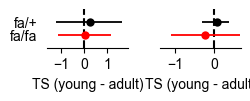

In [15]:
f, axes = plt.subplots(1, 2, figsize=(2.5, 0.5))
plt.subplots_adjust(wspace=0.4)

for ax, ts_, tle in zip(axes, (ts_vehicle, ts_change), ('Vehicle', 'Empagliflozin')):
    ax = forestplot_oz(ax, ts_);
    # ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('TS (young - adult)')
    
axes[0].set_xlim(-1.6,1.9)
axes[1].set_xlim(-1.4, 0.7)

# axes[1].set_xticks([-0.005, 0, 0.005], [-0.005, 0, 0.005])
# axes[0].set_xticks([-0.01, 0, 0.01], [-0.01, 0, 0.01])

axes[1].set_yticks([],[])
# plt.tight_layout()
# f.savefig(PLOT_DIR / "ts_ExcretionNa_CompareAgeForGtypsSexes.pdf", bbox_inches="tight")

## Compute and plot TS representing the difference between males and females

In [16]:
ts_change, ts_vehicle = (
    {
        "fa/fa":  t_groups["fa/fa:male:adult"] - t_groups["fa/fa:female:adult"],
        # "young fa/fa":   t_groups["fa/fa:male:young"] - t_groups["fa/fa:female:young"],
        "fa/+":   t_groups["fa/+:male:adult"] - t_groups["fa/+:female:adult"],
        # "young fa/+":   t_groups["fa/+:male:young"] - t_groups["fa/+:female:young"],
        # "adult": (t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"] + t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"])/2,
        # "young": (t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"] + t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"])/2,
        # "overall": (t_groups["fa/fa:young"]+t_groups["fa/fa:old"])/2 - (t_groups["fa/+:young"]+t_groups["fa/+:old"])/2,
        
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_sex = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_change))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'fa/fa': 0.9235, 'fa/+': 0.13025}


Vehicle sign probabilities:


{'fa/fa': 0.1545, 'fa/+': 0.0595}

[]

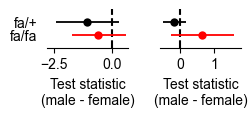

In [17]:
f, axes = plt.subplots(1, 2, figsize=(2.5, 0.5))
plt.subplots_adjust(wspace=0.4)

for ax, ts_, tle in zip(axes, (ts_vehicle, ts_change), ('Vehicle', 'Empagliflozin')):
    ax = forestplot_oz(ax, ts_);
    # ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Test statistic\n(male - female)')
    
axes[0].set_xlim(-2.8,.7)
axes[1].set_xlim(-.6, 1.8)
# axes[0].set_xticks([-0.005, 0, 0.005], [-0.005, 0, 0.005])
# axes[1].set_xticks([-0.01, 0], [-0.01, 0])
axes[1].set_yticks([],[])

# f.savefig(PLOT_DIR / "ts_ExcretionNa_CompareSexesForGtypAges.pdf", bbox_inches="tight")

## Show sign probabilities in tables

In [18]:
sp_all = pd.concat(objs=(sign_probabilities_change,
                sign_probabilities_gtyp,
                sign_probabilities_age, 
                sign_probabilities_sex), 
                   keys=('excrNa',
                         'fa/fa - fa/+',
                         'young - adult', 
                         'male - female'), 
                   names=('contrast', 
                          'group'))
# sp_all.to_csv('../sp_tables/ExcretionNa.csv')
sp_all

change change_signif  vehicle vehicle_signif
contrast      group                                                       
excrNa        fa/fa adult M  0.99300             *      NaN            NaN
              fa/fa young M  0.97275                    NaN            NaN
              fa/+ adult M   0.16450                    NaN            NaN
              fa/+ young M   0.30550                    NaN            NaN
              fa/fa adult F  0.86575                    NaN            NaN
              fa/fa young F  0.65725                    NaN            NaN
              fa/+ adult F   0.67100                    NaN            NaN
              fa/+ young F   0.78075                    NaN            NaN
fa/fa - fa/+  M adult        0.99300             *  0.90275               
              M young        0.97575             *  0.86650               
              M              0.99450             *  0.93075               
              F adult        0.82525                0.79425               
              F young        0.54750                0.64925               
              F              0.72475                0.76100               
young - adult fa/fa          0.31025                0.52350               
              fa/+           0.68325                0.64650               
male - female fa/fa          0.92350                0.15450               
              fa/+           0.13025                0.05950